In [1]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# import dynlib
# Note: the package may only work for conda/analysis3-25.12
import os
import sys
os.environ['DYNLIBDIR']='/g/data/gb02/public/tools/Wx/dynlib-1.6.1.dev7+g2e093da-py3.11.egg/'
sys.path.append(os.environ['DYNLIBDIR'])
import dynlib
from dynlib import utils

In [3]:
def assign_weatherfeature_coords(ds):
    # suqeeze
    ds = ds.squeeze()
    
    # get names of y and x dims
    y_dim = list(ds.dims)[1]
    x_dim = list(ds.dims)[2]
    
    # get numbers of y and x dims
    ny = ds.sizes[y_dim]
    nx = ds.sizes[x_dim]
    
    # assign coords
    lat_vals = np.arange(-90, 90.5, 0.5)
    lon_vals = -180 + 0.5 * np.arange(nx)
    ds = ds.assign_coords({y_dim: (y_dim, lat_vals)})
    ds = ds.assign_coords({x_dim: (x_dim, lon_vals)})
    
    # rename y- and x-coordiante as lat and lon
    ds = ds.rename({y_dim: 'latitude', x_dim: 'longitude'})

    # check longitude
    if ds.longitude.size != 720:
        ds = ds.sel(longitude=np.arange(-180, 180, .5))

    return ds

In [4]:
# directories
workdir = '/g/data/if69/cj0591/GC26_energy_synoptics'
demand_datadir = f'{workdir}/data/wind_capacity_factor'
weather_datadir = f'{workdir}/data/weatherfeatures.era5'

In [5]:
# year and month
year = 2018
month = 1

Read demand dataset

In [12]:
# open demand dataset
dmd = xr.open_dataset(f'{demand_datadir}/wind_capacity_factor_van_der_Wiel_era5_hourly_{year}_Aus.nc')
dmd = dmd.rename({'lat': 'latitude', 'lon': 'longitude'})
dmd = dmd.sel(time=f'{year}-{str(month).zfill(2)}')      # select only one month
dmd = dmd.sel(latitude=slice(None, None, -1))

# interpolate the 0.25 to 0.5
# to match with weather object
lat_05 = np.arange(-45, -10+.5, .5)
lon_05 = np.arange(110, 155+.5, .5)
dmd_05 = dmd.interp(latitude=lat_05, longitude=lon_05)

Read weather feature dataset

In [19]:
# one month exmaple
year = 2018; month = 1

# cyclone
cyclone = xr.open_dataset(f'{weather_datadir}/mincl/cdf/{year}/C{year}_{str(month).zfill(2)}.nc')
cyclone = assign_weatherfeature_coords(cyclone).sel(latitude=lat_05,longitude=lon_05)
cyclone = cyclone[['INPUT']]

# anticyclone
anticyclone = xr.open_dataset(f'{weather_datadir}/maxcl/cdf/{year}/A{year}_{str(month).zfill(2)}.nc')
anticyclone = assign_weatherfeature_coords(anticyclone).sel(latitude=lat_05,longitude=lon_05)
anticyclone = anticyclone[['FLAG']]

# front
front = xr.open_dataset(f'{weather_datadir}/fronts/cdf.700hPa/{year}/F{year}_{str(month).zfill(2)}.nc')
front = assign_weatherfeature_coords(front).sel(latitude=lat_05,longitude=lon_05)
front = front[['FRONT']]

# wcb
wcb = xr.open_dataset(f'{weather_datadir}/wcb/cdf.1hourly/{year}/hit_{year}_{str(month).zfill(2)}.nc')
wcb = assign_weatherfeature_coords(wcb).sel(latitude=lat_05,longitude=lon_05)
wcb = wcb[['GT800', 'MIDTROP', 'LT400']]

Prepare for attribution

In [52]:
# create new dataset with the dimensions and coordiantes as in weather feature
dims = list(cyclone.dims)
coords = {dim: cyclone[dim].values for dim in dims}

# rename varaiables to 
dataset = xr.Dataset(None, coords = cyclone.coords)

# add demand
dataset['dmd'] = dmd_05['capacity_factor']

# add features
dataset['C']  = cyclone.INPUT>0
dataset['F']  = front.FRONT>0
dataset['W']  = wcb.MIDTROP>0
dataset['A']  = anticyclone.FLAG>0

# mask condition
masks_conditions = [
    ('C', lambda x: (x.C > 0)),
    ('F', lambda x: (x.W > 0)),
    ('W', lambda x: (x.F > 0)),
    ('A', lambda x: (x.A > 0)),
    # add more masks as needed
]

# add total demand
dataset['tot_dmd'] = dataset['dmd']

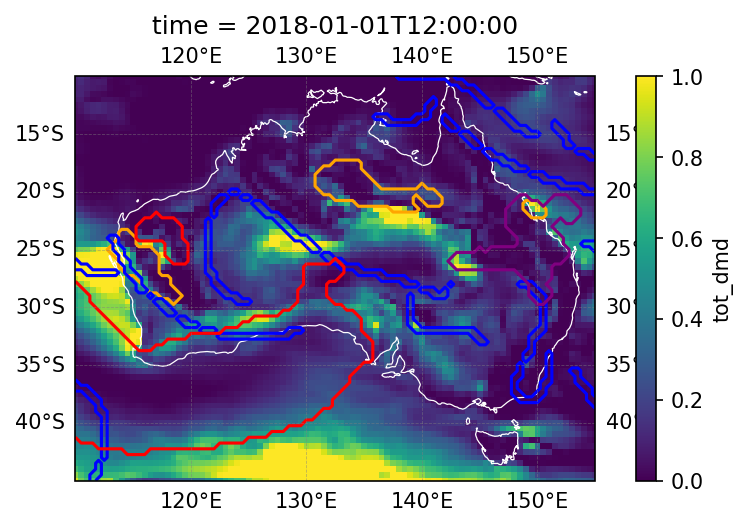

In [77]:
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()
fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)

dataset['tot_dmd'][12].plot(ax=ax,transform=datacrs)
dataset['C'][12].plot.contour(colors='orange',ax=ax,transform=datacrs)
dataset['F'][12].plot.contour(colors='blue',ax=ax,transform=datacrs)
dataset['W'][12].plot.contour(colors='purple',ax=ax,transform=datacrs)
dataset['A'][12].plot.contour(colors='red',ax=ax,transform=datacrs)
gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='w', lw=.6)
ax.set_extent([110, 155, -45, -10], crs=datacrs)
plt.show()

In [79]:
# Do the attribution (needs to be negtative)
# For details of attribution function
# See https://folk.uib.no/csp001/dynlib_doc/
dmd_attribution = utils.attribute_to_features(dataset, masks_conditions, var = 'tot_dmd', factor=-1)

/g/data/gb02/public/tools/Wx/dynlib-1.6.1.dev7+g2e093da-py3.11.egg/dynlib/utils.py:1028: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in range(da.dims['time']):


In [80]:
dmd_attribution

<xarray.Dataset> Size: 615MB
Dimensions:    (time: 744, latitude: 71, longitude: 91)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2018-01-01 ... 2018-01-31T23:00:00
  * latitude   (latitude) float64 568B -45.0 -44.5 -44.0 ... -11.0 -10.5 -10.0
  * longitude  (longitude) float64 728B 110.0 110.5 111.0 ... 154.0 154.5 155.0
Data variables: (12/16)
    U          (time, latitude, longitude) float64 38MB 1.0 1.0 1.0 ... 0.0 0.0
    A          (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    W          (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    WA         (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    F          (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    FA         (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    ...         ...
    CW         (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    CWA        (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    CF         (time, latitude, longitude) float64 38MB 0.0 0.0 ... 0.1233
    CFA        (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    CFW        (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0
    CFWA       (time, latitude, longitude) float64 38MB 0.0 0.0 0.0 ... 0.0 0.0

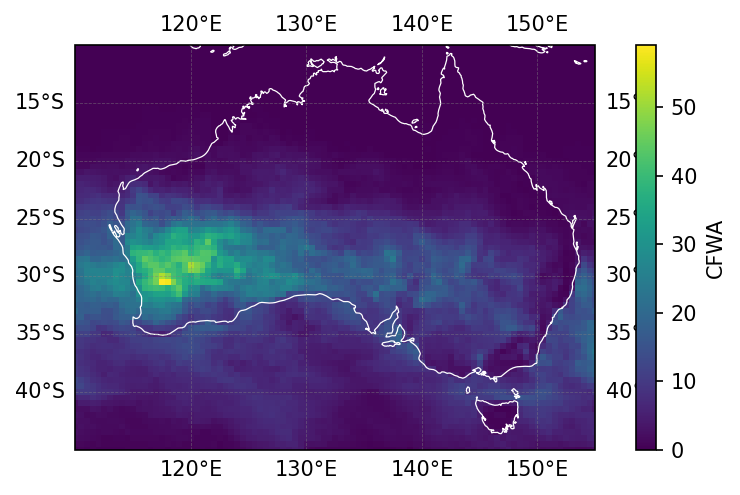

In [85]:
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()
fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)

dmd_attribution['CFWA'].sum('time').plot(ax=ax,transform=datacrs)
gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='w', lw=.6)
ax.set_extent([110, 155, -45, -10], crs=datacrs)
plt.show()